### Preorder Traversal of Binary Tree

Preorder Traversal is a method to traverse a tree such that for each node, you first visit the node itself, then traverse its left subtree, and finally traverse its right subtree.

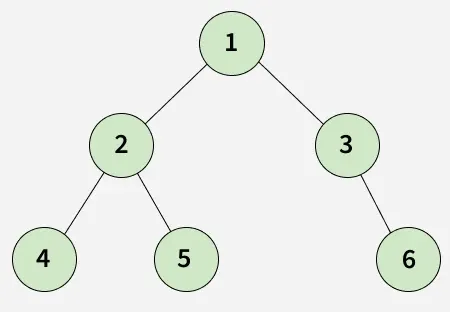

Output: [1, 2, 4, 5, 3, 6]

Explanation: Preorder Traversal (Root -> Left -> Right). 

Visit 1 -> 2 -> 4 -> 5 -> 3 -> 6, resulting in 1 2 4 5 3 6.     


Reference:

1. https://www.geeksforgeeks.org/dsa/preorder-traversal-of-binary-tree/


Note: Also check for applications and other uses in the above link 

#### Binary Tree Traversal - Approach #1 Using Recursion

The main idea is to traverse the tree recursively, starting from the root node, first visit the root node itself, then completely traverse the left subtree, and finally completely traverse the right subtree.

Time Complexity: O(n)

Auxiliary Space: O(h), h is the height of the tree

    In the worst case, h can be the same as n (when the tree is a skewed tree)
    In the best case, h can be the same as log n (when the tree is a complete tree)


In [5]:
class Node: 
    def __init__(self, key):
        self.key = key 
        self.left = None 
        self.right = None 

class BinaryTree:
    def __init__(self):
        self.root = None 

    # insert using recursive approach 
    def insert(self, key):
        if not self.root:
            self.root = Node(key)
            return 
        self._insert(self.root, key)

    def _insert(self, node, key):
        if not node.left:
            node.left = Node(key)
        elif not node.right:
            node.right = Node(key)
        else:
            # Insert recursively into left subtree (basic strategy)
            self._insert(node.left, key)

    # tree traversals - recursive approach 
    
    def preorder(self, node):
        if node: 
            print (node.key, end=" ")
            self.preorder(node.left)
            self.preorder(node.right)

  

bt = BinaryTree()
bt.insert(1)
bt.insert(2)
bt.insert(3)
bt.insert(4)
bt.insert(5)
bt.insert(6)

print("\nPreorder:", end=" ")
bt.preorder(bt.root)



Preorder: 1 2 4 6 5 3 

#### No different just another way of doing the same thing

In [6]:
class Node:
    def __init__(self, data):
        self.data = data
        self.left = None
        self.right = None

def preOrder(node, res):
    if not node:
        return

    # Visit the current node first
    res.append(node.data)

    # Traverse the left subtree
    preOrder(node.left, res)

    # Traverse the right subtree
    preOrder(node.right, res)

if __name__ == "__main__":
    
    # Create binary tree
    #       1
    #      /  \
    #    2     3
    #   / \     \
    #  4   5     6
    
    root = Node(1)
    root.left = Node(2)
    root.right = Node(3)
    root.left.left = Node(4)
    root.left.right = Node(5)
    root.right.right = Node(6)
    
    result = []
    preOrder(root, result)

    print(*result)

1 2 4 5 3 6


#### Iterative Preorder Traversal

Given a binary tree, write an iterative function to print the Preorder traversal of the tree. 

The Preorder traversal follows the order: 

    Root → Left → Right.

Input:
           1
         /   \
        2     3
      /  \
     4    5

Output: 1 2 4 5 3

Explanation: Preorder traversal (Root->Left->Right) of the tree is 1 2 4 5 3.    

So you have 3 approaches for this problem 

[Naive Approach] Simple Iterative Preorder (with stack) - O(n) time and O(n) space
[Better Approach] Iterative Preorder with Current Pointer (with stack) - O(n) time and O(n) space
[Expected Approach] Preorder Morris Traversal - O(n) time and O(1) space

#### [Naive Approach] Simple Iterative Preorder (with stack) - O(n) time and O(n) space

Following is a simple stack based iterative process to print Preorder traversal. 

 1. Create an empty stack and push root node to stack. 
 2. Do the following while is not empty. 
 
        1. Pop an item from the stack and print it. 
        2. Push right child of a popped item to stack 
        3. Push left child of a popped item to stack

The right child is pushed before the left child to make sure that the left subtree is processed first.
📚 Why Push Right First?
        A stack is Last-In, First-Out (LIFO).
        When you pop from the stack, the last pushed node is processed first.
        To maintain preorder (root → left → right):

                - You visit the root immediately.

                - You want the left child to be processed before the right child.

                - Therefore, you must push the right child first, then the left child.

                - This way, the left child sits on top of the stack and gets popped next.

    A
   / \
  B   C

Steps:

1. Start with stack = [A].

2. Pop A → visit → res = [A].

3. Push right (C), then left (B). Stack = [C, B].

4. Pop B → visit → res = [A, B].

5. B has no children → stack = [C].

6. Pop C → visit → res = [A, B, C].

✅ Correct preorder: A → B → C.
              

In [ ]:
class Node: 
    def __init__(self, data):
        self.data = data 
        self.left = None 
        self.right = None 

def preOrder(root):
    # result list
    res = []
    # check if the tree is empty 
    if root is None:
        return res 
    # stack to hold the root
    stack = [root]    

    while stack:
        # pop the top most node
        curr = stack.pop()
        # visit it - i.e. get the data / value of the node
        res.append(curr.data)

        # push the right child first 
        if curr.right:
            stack.append(curr.right)
        # push the left child next 
        if curr.left:
            stack.append(curr.left)

    return res 

if __name__ == '__main__':
    root = Node(1)
    root.left = Node(2)
    root.right = Node(3)
    root.left.left = Node(4)
    root.left.right = Node(5)

    preorder = preOrder(root)
    print(' '.join(map(str, preorder)))

    

1 2 4 5 3


#### Approach #2 [Better Approach] Iterative Preorder with Current Pointer (with stack) 

**- O(n) time and O(n) space**

In the previous solution we can see that the left child is popped as soon as it is pushed to the stack, therefore it is not required to push it into the stack. 

The idea is to start traversing the tree from the root node and keep printing the left child while exists and simultaneously, push the right child of every node in an auxiliary stack. Once we reach a null node, pop a right child from the auxiliary stack and repeat the process while the auxiliary stack is not empty. 



In [ ]:
# Better Approach 

class Node:
    def __init__(self, data):
        self.data = data
        self.left = None
        self.right = None


def preOrder(root):
    # store the result here
    res = []
    # Edge case, if tree is empty, just return 
    if root is None:
        return res

    # Stack to hold the right children
    stack = []
    # start from the root
    curr = root

    # execute this loop until both the stack and curr are empty
    while stack or curr:
        # traverse down to the left side

        while curr:
            print(f"At begining, res={res}, Stack: {[node.data for node in stack]} ", )
            # add the current node value
            res.append(curr.data)
            # if right child exists, save for later
            if curr.right:
                stack.append(curr.right)
            # Move to the left child
            curr = curr.left
            print(f"After pushing right child, res={res}, Stack: {[node.data for node in stack]} ", )           

        # if stack has a value means there is no left child at (this) level, 
        # So pop the saved right child from the stack
        if stack:
            curr = stack.pop()
            print(f"After popping right child, res={res}, Stack: {[node.data for node in stack]} ", )
        

    return res


if __name__ == '__main__':
    root = Node('A')
    root.left = Node('B')
    root.right = Node('C')
    root.left.left = Node('D')
    root.left.right = Node('E')

    res = preOrder(root)

    print(' '.join(map(str, res)))

At begining, res=[], Stack: [] 
After pushing right child, res=['A'], Stack: ['C'] 
At begining, res=['A'], Stack: ['C'] 
After pushing right child, res=['A', 'B'], Stack: ['C', 'E'] 
At begining, res=['A', 'B'], Stack: ['C', 'E'] 
After pushing right child, res=['A', 'B', 'D'], Stack: ['C', 'E'] 
After popping right child, res=['A', 'B', 'D'], Stack: ['C'] 
At begining, res=['A', 'B', 'D'], Stack: ['C'] 
After pushing right child, res=['A', 'B', 'D', 'E'], Stack: ['C'] 
After popping right child, res=['A', 'B', 'D', 'E'], Stack: [] 
At begining, res=['A', 'B', 'D', 'E'], Stack: [] 
After pushing right child, res=['A', 'B', 'D', 'E', 'C'], Stack: [] 
A B D E C


       A
      / \
     B   C
    / \
   D   E

1st iteration, curr = A, res = [A], stack=[C], curr = B
2nd iteration, curr = B, res = [A, B], stack=[C, E]


👉 So, when you see stack = [root], it’s not storing the whole tree — just the root node reference. The stack grows and shrinks as children are added and popped, and the top of the stack is always the last element.



⚖️ Key Difference
- Method 2: Walks down the left side, only storing right children for later. The stack is more “minimal.”
- Method 1: Treats the stack as the full driver of traversal. Both left and right children are pushed, and order is controlled by push order (right first, then left).
Both yield the same traversal, but the mental model differs:
- Method 2 feels like “recursion simulation.”
- Method 1 feels like “explicit stack driving the process.”


# [Expected Approach] Preorder Morris Traversal - O(n) time and O(1) space



Morris Traversal is a tree traversal technique that allows you to traverse a binary tree without using recursion or a stack. The Preorder Morris Traversal algorithm works by manipulating the tree's pointers, specifically by utilizing the inorder predecessor of each node.

Algorithm for Preorder Morris Traversal:

1. If the left child of the current node is NULL:

    Print the current node's data (since it is the root of the subtree).
    Move to the right child of the current node.

2. If the left child of the current node is NOT NULL:

    Find the inorder predecessor of the current node: The inorder predecessor is the rightmost node of the left subtree of the current node.

Two cases arise:

a) The right child of the inorder predecessor already points to the current node:

    This means we've already visited this node, so we can set the right child of the inorder predecessor to NULL.
    Move to the right child of the current node.

b) The right child of the inorder predecessor is NULL:

    Set the right child of the inorder predecessor to point to the current node.
    Print the current node's data.
    Move to the left child of the current node (this is the new node to visit next).

3. Repeat the process until the current node is NULL.

🌳 What Is Morris Traversal?
- It’s a way to traverse a binary tree without recursion and without a stack.
- It uses the concept of threaded binary trees: temporarily linking a node’s predecessor (rightmost node in its left subtree) back to the current node.
- This allows us to return to a node after finishing its left subtree, without needing extra memory.


https://www.geeksforgeeks.org/dsa/iterative-preorder-traversal/

In [15]:
class Node: 
    def __init__(self, val):
        self.val = val 
        self.left = None
        self.right = None

def morrisPreOrder(node):
    result = []
    while node:
        if node.left is None:
            result.append(node.val)
            node = node.right
        else:
            current = node.left 
            while current.right and current.right != node:
                current = current.right
            
            if current.right == node: 
                current.right = None 
                node = node.right

            else:
                result.append(node.val)
                current.right = node
                node = node.left
    return result


if __name__ == '__main__':
    root = Node('A')
    root.left = Node('B')
    root.right = Node('C')
    root.left.left = Node('D')
    root.left.right = Node('E')

    res = morrisPreOrder(root)    

    print (res)
                

['A', 'B', 'D', 'E', 'C']


Variables:
- node: current node being processed
- current: predecessor (rightmost node in left subtree)
- result: list of visited nodes


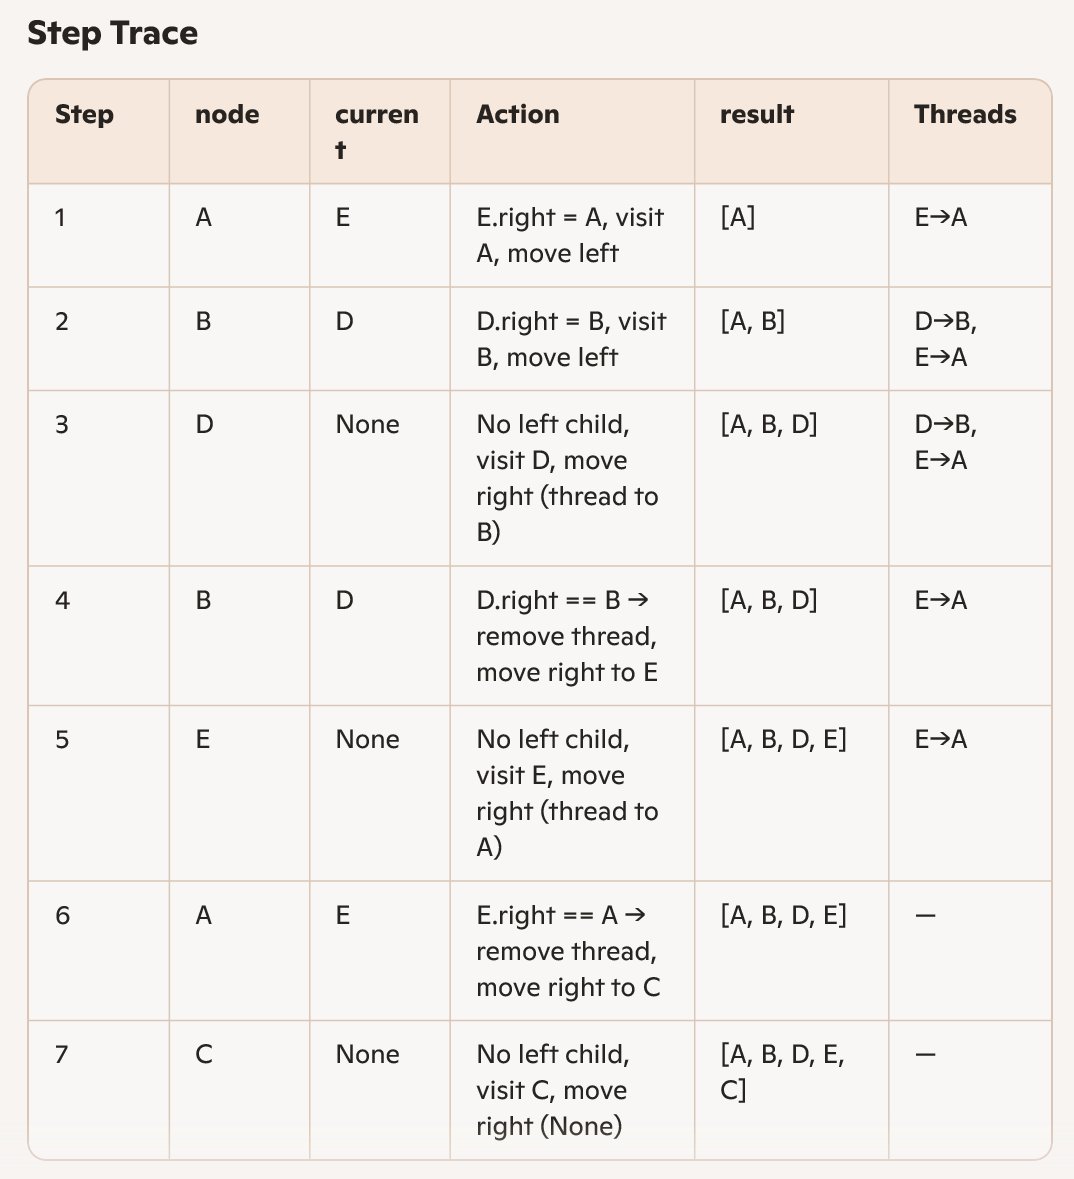






📜 Code Walkthrough

🔎 Key Ideas
- If no left child: Visit the node, then move right.
- If left child exists:
- Find the inorder predecessor (rightmost node in left subtree).
- If predecessor’s right pointer is None, make it point back to the current node (create a temporary thread), visit current, and move left.
- If predecessor’s right pointer already points to current, remove the thread and move right.

🖼 Example Trace (Tree: A–B–C–D–E)
       A
      / \
     B   C
    / \
   D   E


Steps:
- At A → has left child → predecessor is E → thread E.right = A → visit A → move left to B.
- At B → has left child → predecessor is D → thread D.right = B → visit B → move left to D.
- At D → no left child → visit D → move right (threaded back to B).
- At B again → predecessor D.right == B → remove thread → move right to E.
- At E → no left child → visit E → move right (threaded back to A).
- At A again → predecessor E.right == A → remove thread → move right to C.
- At C → no left child → visit C → move right (None).
Result: [A, B, D, E, C]

⚖️ Difference from Stack Methods
|  |  |  | 
|  |  |  | 
|  |  |  | 
|  |  |  | 
|  |  |  | 



👉 So Morris Preorder is clever: it achieves traversal with constant extra space, but at the cost of temporarily altering the tree structure (which is restored afterward).
Would you like me to also show a diagram of how threads are created and removed during traversal? That visual usually makes Morris traversal “click” instantly.


⚖️ Scalability for Large Trees
Recursive Preorder
- Simple, but recursion depth = tree height.
- For very large or skewed trees, recursion can hit stack overflow.
- Space complexity: O(h), where h = height.
Iterative Preorder (stack‑based)
- Avoids recursion, but stack size can still grow to O(h).
- Works fine for large trees, but memory overhead grows with depth.
Morris Preorder
- No recursion, no stack.
- Space complexity: O(1) (constant extra space).
- Time complexity: O(n), but each edge is traversed at most twice (once to create a thread, once to remove it).
- Scales extremely well for very large trees because it doesn’t depend on tree height.
👉 Enterprise‑level / very large trees: Morris traversal is the most scalable because it guarantees O(1) extra space. The trade‑off is that it temporarily modifies the tree (threads), but it restores it afterward
